In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DS_ch = df[(df['job_country']== 'Chile') & (df['job_title_short'] == 'Data Scientist')]

In [3]:
df_DS_ch['job_posted_month_no']= df_DS_ch['job_posted_date'].dt.month

In [4]:
df_DS_ch_explode = df_DS_ch.explode('job_skills')

In [8]:
df_DS_ch_pivot = df_DS_ch_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_DS_ch_pivot.loc['Total'] = df_DS_ch_pivot.sum()
df_DS_ch_pivot = df_DS_ch_pivot[df_DS_ch_pivot.loc['Total'].sort_values(ascending=False).index]
df_DS_ch_pivot =df_DS_ch_pivot.drop('Total')
df_DS_ch_pivot

job_skills,python,sql,r,power bi,aws,tableau,gcp,pandas,excel,azure,...,selenium,cognos,jquery,debian,node.js,nltk,spring,terraform,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,71,55,36,18,8,13,13,13,12,9,...,0,0,0,0,0,1,0,0,0,0
2,52,40,13,12,3,13,5,14,18,4,...,0,0,0,0,0,0,0,0,0,0
3,76,70,26,32,28,29,26,20,16,11,...,0,0,0,0,0,0,0,0,0,0
4,156,123,56,60,57,52,53,28,16,29,...,0,0,0,0,0,0,0,0,0,0
5,60,48,14,18,23,18,27,13,7,11,...,0,0,0,0,0,0,0,0,0,0
6,65,53,29,19,22,23,16,13,13,9,...,0,0,1,0,0,0,0,0,0,0
7,101,102,31,35,19,28,18,39,16,9,...,0,0,0,0,0,0,0,0,0,0
8,104,89,48,22,29,25,25,26,26,18,...,1,0,0,1,1,0,0,0,0,0
9,79,66,40,17,21,11,15,21,15,15,...,0,0,0,0,0,0,0,0,0,1


In [10]:
ds_total = df_DS_ch.groupby('job_posted_month_no').size()


In [11]:
df_DS_ch_percent = df_DS_ch_pivot.div(ds_total/100, axis=0)


In [12]:
df_DS_ch_percent = df_DS_ch_percent.reset_index()
df_DS_ch_percent['job_posted_month'] = df_DS_ch_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DS_ch_percent = df_DS_ch_percent.set_index('job_posted_month')
df_DS_ch_percent = df_DS_ch_percent.drop(columns='job_posted_month_no')

df_DS_ch_percent

job_skills,python,sql,r,power bi,aws,tableau,gcp,pandas,excel,azure,...,selenium,cognos,jquery,debian,node.js,nltk,spring,terraform,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,61.206897,47.413793,31.034483,15.517241,6.896552,11.206897,11.206897,11.206897,10.344828,7.758621,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.862069,0.000000,0.000000,0.000000,0.000000
Feb,65.822785,50.632911,16.455696,15.189873,3.797468,16.455696,6.329114,17.721519,22.784810,5.063291,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,74.509804,68.627451,25.490196,31.372549,27.450980,28.431373,25.490196,19.607843,15.686275,10.784314,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,57.992565,45.724907,20.817844,22.304833,21.189591,19.330855,19.702602,10.408922,5.947955,10.780669,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,58.823529,47.058824,13.725490,17.647059,22.549020,17.647059,26.470588,12.745098,6.862745,10.784314,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,63.106796,51.456311,28.155340,18.446602,21.359223,22.330097,15.533981,12.621359,12.621359,8.737864,...,0.000000,0.000000,0.970874,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,55.801105,56.353591,17.127072,19.337017,10.497238,15.469613,9.944751,21.546961,8.839779,4.972376,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,52.791878,45.177665,24.365482,11.167513,14.720812,12.690355,12.690355,13.197970,13.197970,9.137056,...,0.507614,0.000000,0.000000,0.507614,0.507614,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,47.878788,40.000000,24.242424,10.303030,12.727273,6.666667,9.090909,12.727273,9.090909,9.090909,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.606061


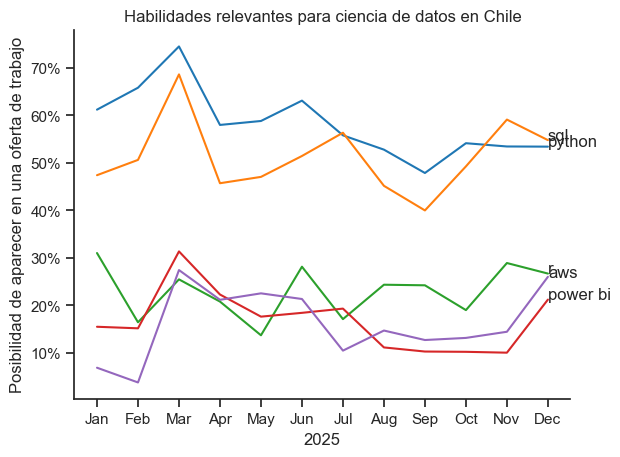

In [21]:
df_plot = df_DS_ch_percent.iloc[:,:5]
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Habilidades relevantes para ciencia de datos en Chile')
plt.ylabel('Posibilidad de aparecer en una oferta de trabajo')
plt.xlabel('2025')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter())

for i in range(5):
    plt.text(11, df_plot.iloc[-1, i], df_plot.columns[i])